<a href="https://colab.research.google.com/github/vedantpande1728/nlp-pipeline-demo/blob/main/nlp_colab_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from gensim.models import Word2Vec

sentences = [
    ['the', 'king', 'rules', 'the', 'kingdom'],
    ['the', 'queen', 'rules', 'the', 'kingdom'],
    ['the', 'prince', 'rules', 'the', 'kingdom'],
    ['an', 'apple', 'is', 'a', 'tasty', 'fruit' ],
    ['a', 'banana', 'is', 'a', 'tasty', 'fruit' ],
    ['a', 'cherry', 'is', 'a', 'tasty', 'fruit' ],
]

print("--- Training Models ---")

model_cbow = Word2Vec(sentences, vector_size=10, window=2, min_count=1, sg=0, epochs=100)
print("CBOW model trained successfully")

model_skipgram = Word2Vec(sentences, vector_size=10, window=2, min_count=1, sg=1, epochs=100)
print("SKI model trained successfully")

def test_similarities(model, model_name):
  print(f"---Semantic Similarities using {model_name}---")

  sim_royal = model.wv.similarity('queen', 'king')
  print(f"Similarity ('queen' , 'king'): {sim_royal:.4f}")

  sim_fruit = model.wv.similarity('apple', 'is')
  print(f"Similarity ('appple' , 'mango'): {sim_fruit:.4f}")

  sim_unrelated = model.wv.similarity('queen', 'apple')
  print(f"Similarity of unrelated words('queen', 'apple'): {sim_unrelated:.4f}")
print("-" * 40)


test_similarities(model_cbow, "CBOW")
test_similarities(model_skipgram, "Skipgram")

--- Training Models ---
CBOW model trained successfully
SKI model trained successfully
----------------------------------------
---Semantic Similarities using CBOW---
Similarity ('queen' , 'king'): 0.4354
Similarity ('appple' , 'mango'): 0.0366
Similarity of unrelated words('queen', 'apple'): 0.5059
---Semantic Similarities using Skipgram---
Similarity ('queen' , 'king'): 0.4375
Similarity ('appple' , 'mango'): 0.0347
Similarity of unrelated words('queen', 'apple'): 0.5081


In [ ]:
!pip install gensim --quiet

import gensim
from gensim.models import KeyedVectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Gensim version:", gensim.__version__)

Gensim version: 4.4.0


In [ ]:
import gensim.downloader as api
model = api.load('word2vec-google-news-300')

print(model.most_similar("google"))

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[('google.com', 0.6711485981941223), ('google_yahoo', 0.6488178968429565), ('wikipedia', 0.643608033657074), ('www.google.com', 0.6258559226989746), ('googled', 0.6166064143180847), ('googling', 0.6086059212684631), ('slashdot', 0.5964587330818176), ('lifehacker', 0.5948858857154846), ('gizmodo', 0.5884420275688171), ('inurl', 0.5882638692855835)]


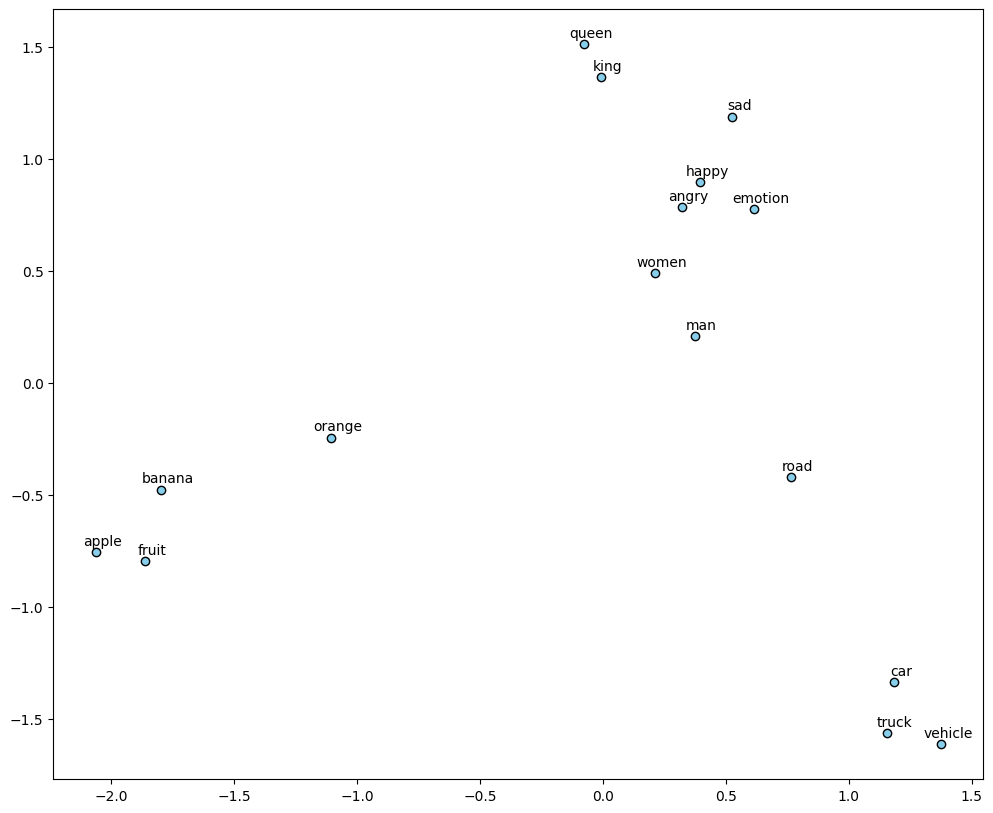

In [ ]:
word_to_visualize = [
    'king','queen','man','women',
    'apple','banana','orange','fruit',
    'car','truck','vehicle','road',
    'happy','sad','angry','emotion'
]

filtered_words = [word for word in word_to_visualize if word in model.key_to_index]
vectors = [model[word] for word in filtered_words]

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)


plt.figure(figsize=(12, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1],edgecolors='k',c='skyblue')

for i, word in enumerate(filtered_words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),textcoords="offset points",xytext=(5, 5),ha='center')